# Cardiovascular Disease Prediction Using Machine Learning

## Project Objective

The objective of this project is to analyze cardiovascular health data and develop machine learning models to predict the presence of cardiovascular disease.

The project includes data preprocessing, exploratory data analysis, data visualization, correlation analysis, comparison of multiple machine learning algorithms, and development of a final cardiovascular disease prediction model.

## Dataset Description

The dataset contains information about patients and several cardiovascular health-related factors.

The main variables include:

- `age` – age of the patient in days
- `gender` – gender category
- `height` – height in centimeters
- `weight` – weight in kilograms
- `ap_hi` – systolic blood pressure
- `ap_lo` – diastolic blood pressure
- `cholesterol` – cholesterol level
- `gluc` – glucose level
- `smoke` – smoking status
- `alco` – alcohol consumption status
- `active` – physical activity status
- `cardio` – target variable indicating the presence or absence of cardiovascular disease

The target variable `cardio` contains two classes:

- `0` – No cardiovascular disease
- `1` – Cardiovascular disease

## Data Preprocessing

The dataset was checked and cleaned before performing analysis and machine learning.

### 1. Missing Values

All columns were checked for missing values. No missing values were found in the dataset.

### 2. Duplicate Records

The dataset was checked for duplicate rows. No duplicate records were found.

### 3. Blood Pressure Cleaning

Some unrealistic blood pressure values were present in the original dataset. To remove clearly invalid observations, the following ranges were used:

- Systolic blood pressure (`ap_hi`): 50–250
- Diastolic blood pressure (`ap_lo`): 30–200

Records outside these ranges were removed.

### 4. Height and Weight Cleaning

Unrealistic height and weight values were also removed using the following ranges:

- Height: 100–220 cm
- Weight: 30–150 kg

### 5. Age Conversion

The original `age` variable was recorded in days. A new variable called `age_years` was created by converting age from days to years.

### 6. BMI Calculation

Body Mass Index (BMI) was calculated using height and weight:

BMI = Weight / Height²

where height is converted from centimeters to meters.

### 7. Final Dataset

After preprocessing, the cleaned dataset contained **68,696 records** and **13 original columns**, with additional derived features such as `age_years` and `bmi`.

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the distribution of the variables and identify relationships between different health-related factors and cardiovascular disease.

The analysis included:

- Distribution of cardiovascular disease
- Age distribution
- Age versus cardiovascular disease
- Gender distribution and its relationship with cardiovascular disease
- Cholesterol distribution and its relationship with cardiovascular disease
- Glucose distribution and its relationship with cardiovascular disease
- Smoking status and cardiovascular disease
- Alcohol consumption and cardiovascular disease
- Physical activity and cardiovascular disease
- Systolic and diastolic blood pressure distributions
- Blood pressure versus cardiovascular disease
- BMI distribution
- BMI versus cardiovascular disease
- Correlation matrix

### Key Findings

- The target variable was approximately balanced between patients with and without cardiovascular disease.
- Patients with cardiovascular disease tended to be older.
- Higher cholesterol levels showed a strong association with cardiovascular disease.
- Higher glucose levels also showed an association with cardiovascular disease.
- Patients with cardiovascular disease generally showed higher blood-pressure values.
- The inactive group had a higher proportion of cardiovascular disease.
- BMI showed a slight positive association with cardiovascular disease.
- Gender, smoking, and alcohol consumption showed relatively weaker associations in this dataset.

These findings are descriptive and indicate associations in the dataset; they do not establish causal relationships.

## Correlation Analysis

A correlation matrix was used to examine the relationships between the numerical variables in the dataset.

The heatmap helps identify variables that have stronger positive or negative relationships with the cardiovascular disease target.

### Key Findings

- Age shows a positive relationship with cardiovascular disease.
- Systolic blood pressure (`ap_hi`) has a positive relationship with cardiovascular disease.
- Diastolic blood pressure (`ap_lo`) also shows a positive relationship.
- Cholesterol and glucose show positive relationships with the target.
- BMI has a weaker positive relationship with cardiovascular disease.
- Smoking, alcohol consumption, and physical activity have relatively weaker linear correlations with the target.

Correlation represents statistical association between variables and does not imply causation.

## Machine Learning Model Development

Machine learning classification models were developed to predict whether a patient has cardiovascular disease.

The target variable was:

- `0` – No cardiovascular disease
- `1` – Cardiovascular disease

The dataset was divided into:

- 80% training data
- 20% testing data

The features were standardized using `StandardScaler`. The same scaling procedure was applied to both training and testing data.

Five machine learning algorithms were evaluated:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Support Vector Machine (SVM)

Model performance was evaluated using accuracy on the test dataset.

## Model Accuracy Comparison

The accuracy results obtained from the five machine learning models are shown below:

| Model | Accuracy |
|---|---:|
| SVM | 73.33% |
| Logistic Regression | 72.65% |
| Decision Tree | 72.59% |
| Random Forest | 70.94% |
| KNN | 69.88% |

### Result

The **Support Vector Machine (SVM)** achieved the highest test accuracy of **73.33%** among the five evaluated models.

Therefore, SVM was selected as the final model for the cardiovascular disease prediction system.

## Final Model Evaluation

The Support Vector Machine (SVM) was selected as the final model because it achieved the highest accuracy among the evaluated models.

### Confusion Matrix

The SVM confusion matrix produced the following results:

| | Predicted No Disease | Predicted Disease |
|---|---:|---:|
| Actual No Disease | 5,478 | 1,463 |
| Actual Disease | 2,201 | 4,598 |

The model correctly classified 5,478 patients without cardiovascular disease and 4,598 patients with cardiovascular disease.

### Classification Report

The SVM achieved:

- Accuracy: **73.33%**
- Disease precision: **76%**
- Disease recall: **68%**
- Disease F1-score: **72%**

The results show that the SVM provides reasonable predictive performance, although some patients are still incorrectly classified.

## Conclusion

This project analyzed a cardiovascular disease dataset and developed machine learning models for cardiovascular disease prediction.

The data was cleaned by handling unrealistic blood-pressure, height, and weight values. Additional features such as age in years and BMI were created. Exploratory data analysis and visualization were performed to identify important patterns in the data.

Five machine learning algorithms were compared: Logistic Regression, KNN, Decision Tree, Random Forest, and SVM.

Among these models, **SVM achieved the highest accuracy of 73.33%** and was selected as the final prediction model.

The final system can take patient health information as input and provide a predicted cardiovascular disease status. The model demonstrates the potential of machine learning for cardiovascular disease prediction, while its predictions should not be considered a medical diagnosis.

ENV Creation


In [30]:
import sys
print(sys.version)

3.10.8 (tags/v3.10.8:aaaf517, Oct 11 2022, 16:50:30) [MSC v.1933 64 bit (AMD64)]


Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries imported successfully!")

All libraries imported successfully!


Load the dataset

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv("cardio_train.csv", sep=";")

# Display the first 5 rows
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Basic Data Inspection

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 70000
Number of columns: 13


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 70000
Columns: 13


Check missing values

In [10]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Check duplicates

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Check the target variable


In [13]:
print(df["cardio"].value_counts())

cardio
0    35021
1    34979
Name: count, dtype: int64


In [14]:
print(df["cardio"].value_counts(normalize=True) * 100)

cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


Check the categorical columns

In [15]:
for column in ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]:
    print("\n", column)
    print(df[column].value_counts().sort_index())


 gender
gender
1    45530
2    24470
Name: count, dtype: int64

 cholesterol
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

 gluc
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

 smoke
smoke
0    63831
1     6169
Name: count, dtype: int64

 alco
alco
0    66236
1     3764
Name: count, dtype: int64

 active
active
0    13739
1    56261
Name: count, dtype: int64

 cardio
cardio
0    35021
1    34979
Name: count, dtype: int64


Check for duplicate rows

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
print(df["cardio"].value_counts())
print(df["cardio"].value_counts(normalize=True) * 100)

cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


In [18]:
for column in ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]:
    print("\n", column)
    print(df[column].value_counts().sort_index())


 gender
gender
1    45530
2    24470
Name: count, dtype: int64

 cholesterol
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

 gluc
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

 smoke
smoke
0    63831
1     6169
Name: count, dtype: int64

 alco
alco
0    66236
1     3764
Name: count, dtype: int64

 active
active
0    13739
1    56261
Name: count, dtype: int64

 cardio
cardio
0    35021
1    34979
Name: count, dtype: int64


check the suspicious values

In [19]:
print("Systolic BP below 50:", (df["ap_hi"] < 50).sum())
print("Systolic BP above 250:", (df["ap_hi"] > 250).sum())

print("Diastolic BP below 30:", (df["ap_lo"] < 30).sum())
print("Diastolic BP above 200:", (df["ap_lo"] > 200).sum())


Systolic BP below 50: 188
Systolic BP above 250: 40
Diastolic BP below 30: 53
Diastolic BP above 200: 953


inspect suspicious records

In [20]:
df[
    (df["ap_hi"] < 50) |
    (df["ap_hi"] > 250) |
    (df["ap_lo"] < 30) |
    (df["ap_lo"] > 200)
][["age", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]].head(20)


,age,gender,height,weight,ap_hi,ap_lo,cardio
228,17489,2,183,98.0,160,1100,1
241,21932,2,157,60.0,160,1000,1
260,18217,1,150,83.0,140,800,1
329,23407,1,176,63.0,160,1000,1
345,18704,1,154,81.0,140,1000,1
473,15226,1,150,95.0,150,1033,1
559,20430,2,173,101.0,200,1000,1
567,21281,1,168,78.0,14,90,1
613,18963,1,165,92.0,140,1000,1
649,18190,1,166,57.0,190,1100,1


In [21]:
# Count valid blood pressure records
valid_bp = (
    (df["ap_hi"] >= 50) & (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 30) & (df["ap_lo"] <= 200)
)

print("Original rows:", len(df))
print("Rows with valid BP:", valid_bp.sum())
print("Rows to remove:", (~valid_bp).sum())

Original rows: 70000
Rows with valid BP: 68781
Rows to remove: 1219


Clean the blood-pressure data

In [22]:
# Remove records with unrealistic blood pressure values
df_clean = df[valid_bp].copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (70000, 13)
Cleaned dataset shape: (68781, 13)


Check height and weight

In [23]:
print("Height below 100 cm:", (df_clean["height"] < 100).sum())
print("Height above 220 cm:", (df_clean["height"] > 220).sum())

print("Weight below 30 kg:", (df_clean["weight"] < 30).sum())
print("Weight above 150 kg:", (df_clean["weight"] > 150).sum())

Height below 100 cm: 26
Height above 220 cm: 1
Weight below 30 kg: 6
Weight above 150 kg: 56


Calculate how many rows will remain

In [24]:
valid_height_weight = (
    (df_clean["height"] >= 100) & (df_clean["height"] <= 220) &
    (df_clean["weight"] >= 30) & (df_clean["weight"] <= 150)
)

print("Rows before height/weight cleaning:", len(df_clean))
print("Rows with valid height/weight:", valid_height_weight.sum())
print("Rows to remove:", (~valid_height_weight).sum())


Rows before height/weight cleaning: 68781
Rows with valid height/weight: 68696
Rows to remove: 85


Create the cleaned dataset

In [25]:
# Create the cleaned dataset
df_clean = df_clean[valid_height_weight].copy()

print("Final cleaned dataset shape:", df_clean.shape)
print("Rows removed in total:", len(df) - len(df_clean))

Final cleaned dataset shape: (68696, 13)
Rows removed in total: 1304


Verify missing values and duplicates

In [26]:
print("Missing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

Missing values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0


Understand the target variable

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df_clean["cardio"].value_counts())
print("\nPercentage:")
print(df_clean["cardio"].value_counts(normalize=True) * 100)

cardio
0    34702
1    33994
Name: count, dtype: int64

Percentage:
cardio
0    50.515314
1    49.484686
Name: proportion, dtype: float64


Plot cardiovascular disease distribution

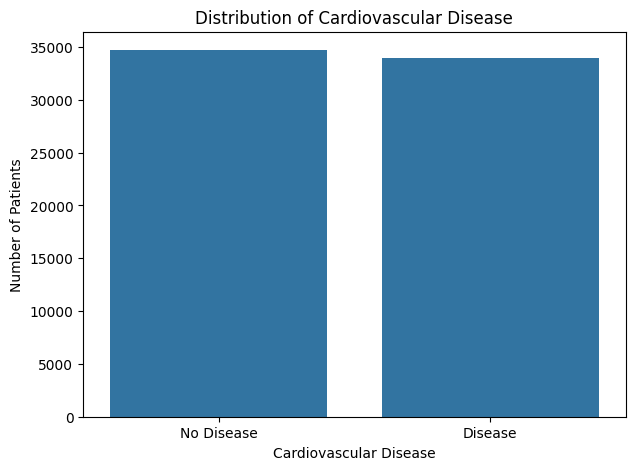

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="cardio")

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

Analyze age

In [32]:
# Convert age from days to years
df_clean["age_years"] = df_clean["age"] / 365.25

# Display some values
df_clean[["age", "age_years"]].head()

,age,age_years
0,18393,50.357290
1,20228,55.381246
2,18857,51.627652
3,17623,48.249144
4,17474,47.841205


Create the age distribution plot

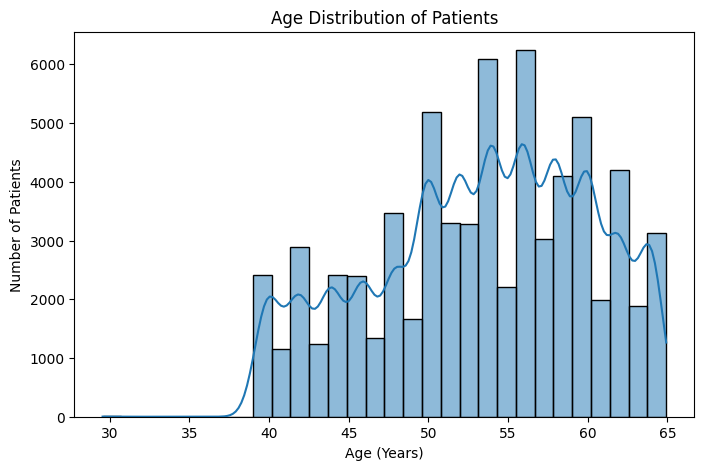

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x="age_years", bins=30, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.show()



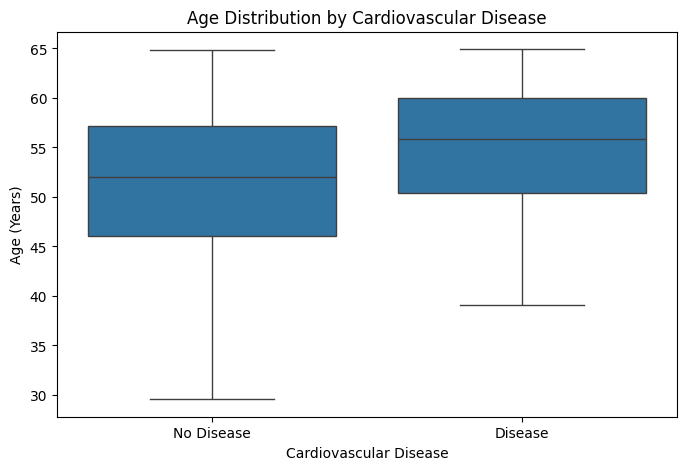

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="cardio", y="age_years")

plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Age (Years)")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

Analyze gender

In [35]:
print(df_clean["gender"].value_counts())

gender
1    44745
2    23951
Name: count, dtype: int64


Visualize gender distribution

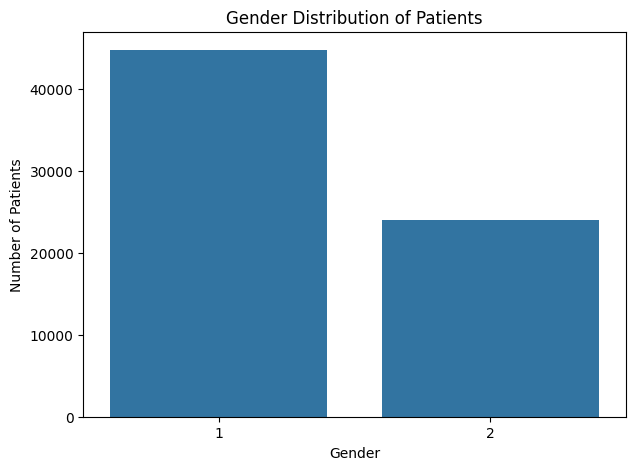

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="gender")

plt.title("Gender Distribution of Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

Gender vs Cardiovascular Disease

In [37]:
gender_cardio = pd.crosstab(
    df_clean["gender"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(gender_cardio)

cardio          0          1
gender                      
1       50.781093  49.218907
2       50.018788  49.981212


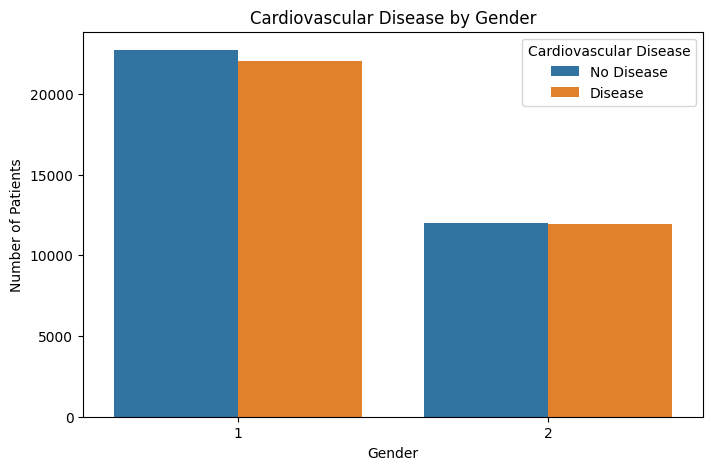

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="gender", hue="cardio")

plt.title("Cardiovascular Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.legend(title="Cardiovascular Disease",
           labels=["No Disease", "Disease"])

plt.show()

Analyze cholesterol

In [40]:
print(df_clean["cholesterol"].value_counts().sort_index())

cholesterol
1    51518
2     9303
3     7875
Name: count, dtype: int64


Visualize cholesterol distribution

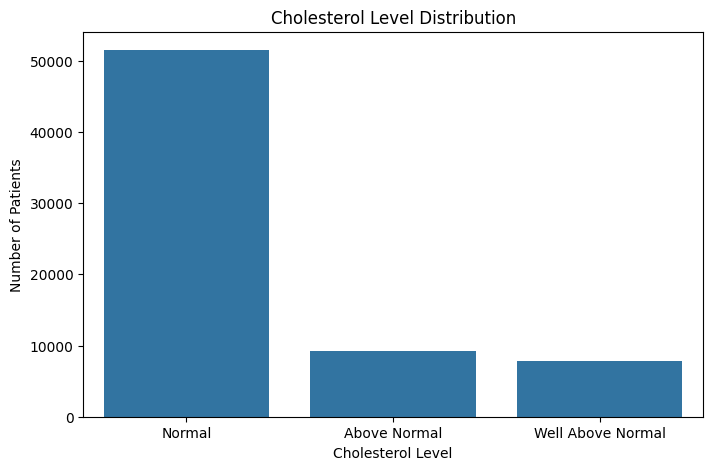

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="cholesterol")

plt.title("Cholesterol Level Distribution")
plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1, 2],
    ["Normal", "Above Normal", "Well Above Normal"]
)

plt.show()

Cholesterol vs Cardiovascular Disease


In [42]:
chol_cardio = pd.crosstab(
    df_clean["cholesterol"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(chol_cardio)

cardio               0          1
cholesterol                      
1            56.448232  43.551768
2            40.341825  59.658175
3            23.720635  76.279365


Visualize this relationship

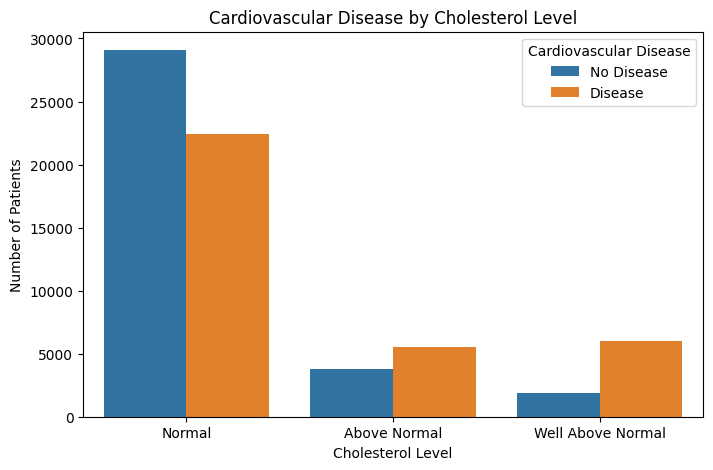

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="cholesterol", hue="cardio")

plt.title("Cardiovascular Disease by Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1, 2],
    ["Normal", "Above Normal", "Well Above Normal"]
)
plt.legend(
    title="Cardiovascular Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

Analyze glucose level

In [44]:
print(df_clean["gluc"].value_counts().sort_index())

gluc
1    58401
2     5068
3     5227
Name: count, dtype: int64


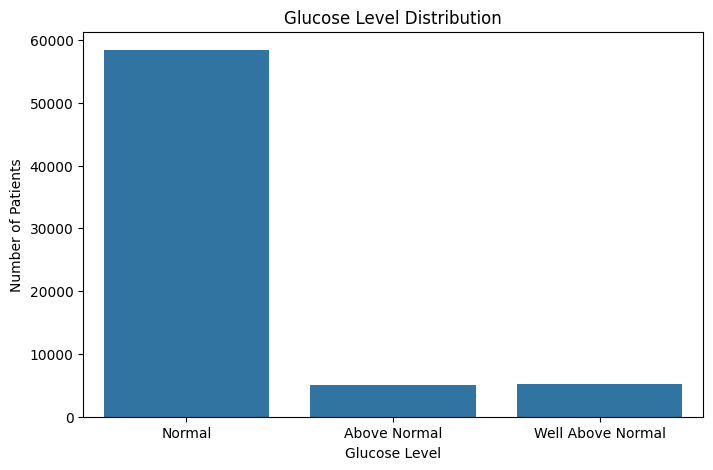

In [45]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="gluc")

plt.title("Glucose Level Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1, 2],
    ["Normal", "Above Normal", "Well Above Normal"]
)

plt.show()

In [46]:
gluc_cardio = pd.crosstab(
    df_clean["gluc"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(gluc_cardio)

cardio          0          1
gluc                        
1       52.437458  47.562542
2       41.120758  58.879242
3       38.148077  61.851923


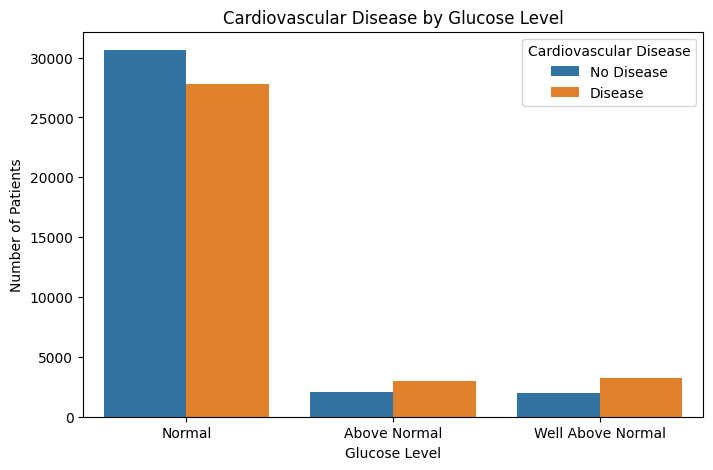

In [47]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="gluc", hue="cardio")

plt.title("Cardiovascular Disease by Glucose Level")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1, 2],
    ["Normal", "Above Normal", "Well Above Normal"]
)
plt.legend(
    title="Cardiovascular Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

Analyze smoking

In [48]:
print(df_clean["smoke"].value_counts().sort_index())

smoke
0    62651
1     6045
Name: count, dtype: int64


In [49]:
smoke_cardio = pd.crosstab(
    df_clean["smoke"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(smoke_cardio)


cardio          0          1
smoke                       
0       50.262566  49.737434
1       53.134822  46.865178


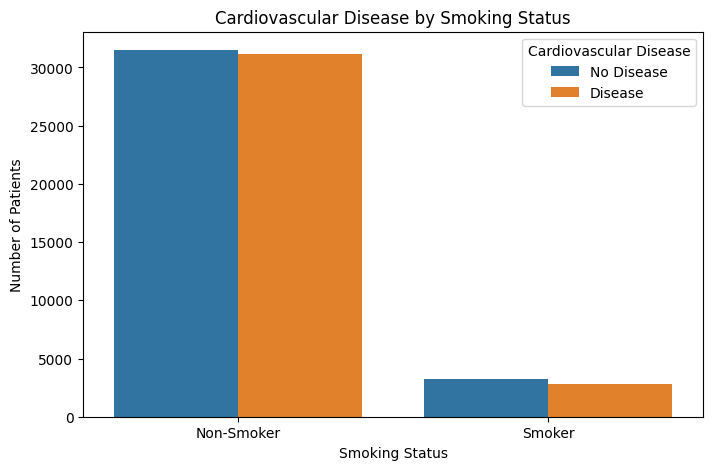

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="smoke", hue="cardio")

plt.title("Cardiovascular Disease by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["Non-Smoker", "Smoker"]
)
plt.legend(
    title="Cardiovascular Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

In [51]:
print(df_clean["alco"].value_counts().sort_index())

alco
0    65014
1     3682
Name: count, dtype: int64


In [52]:
alco_cardio = pd.crosstab(
    df_clean["alco"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(alco_cardio)

cardio          0          1
alco                        
0       50.421448  49.578552
1       52.172732  47.827268


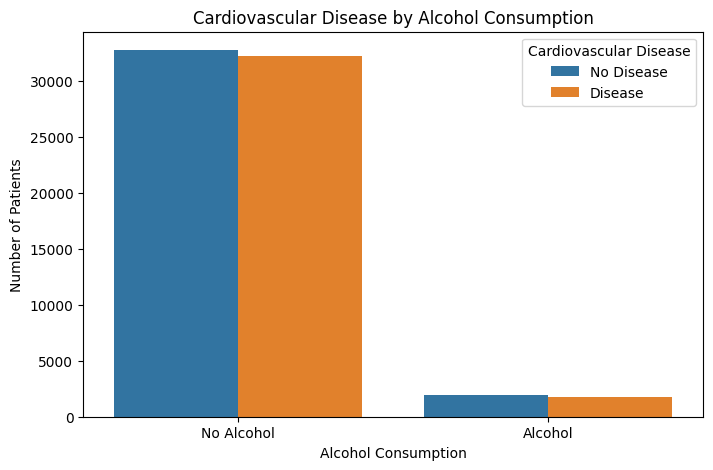

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="alco", hue="cardio")

plt.title("Cardiovascular Disease by Alcohol Consumption")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["No Alcohol", "Alcohol"]
)
plt.legend(
    title="Cardiovascular Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

Analyze physical activity

In [54]:
print(df_clean["active"].value_counts().sort_index())

active
0    13510
1    55186
Name: count, dtype: int64


Physical Activity vs Cardiovascular Disease

In [55]:
active_cardio = pd.crosstab(
    df_clean["active"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(active_cardio)

cardio          0          1
active                      
0       46.720947  53.279053
1       51.444207  48.555793


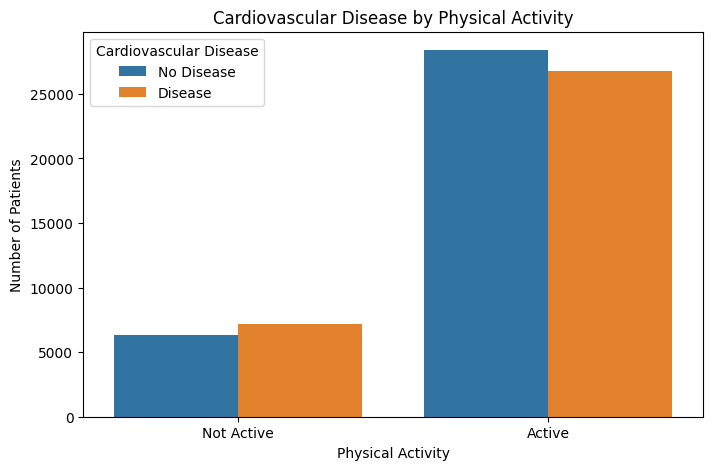

In [56]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="active", hue="cardio")

plt.title("Cardiovascular Disease by Physical Activity")
plt.xlabel("Physical Activity")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["Not Active", "Active"]
)
plt.legend(
    title="Cardiovascular Disease",
    labels=["No Disease", "Disease"]
)

plt.show()

Analyze blood pressure

In [57]:
print("Systolic Blood Pressure:")
print(df_clean["ap_hi"].describe())

print("\nDiastolic Blood Pressure:")
print(df_clean["ap_lo"].describe())

Systolic Blood Pressure:
count    68696.000000
mean       126.606877
std         16.752028
min         60.000000
25%        120.000000
50%        120.000000
75%        140.000000
max        240.000000
Name: ap_hi, dtype: float64

Diastolic Blood Pressure:
count    68696.000000
mean        81.372394
std          9.681686
min         30.000000
25%         80.000000
50%         80.000000
75%         90.000000
max        190.000000
Name: ap_lo, dtype: float64


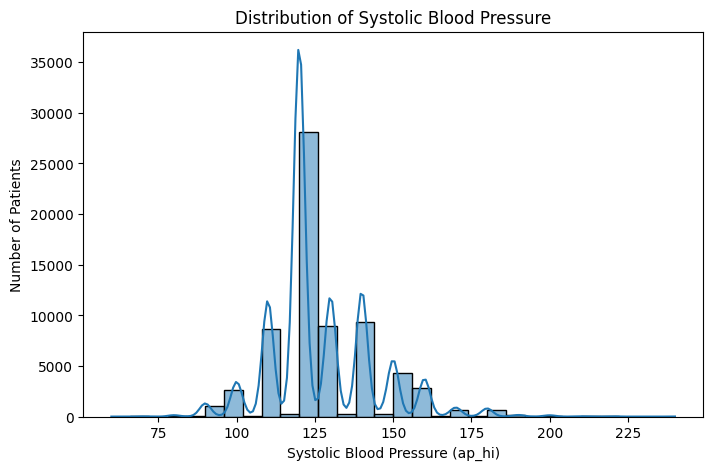

In [58]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x="ap_hi", bins=30, kde=True)

plt.title("Distribution of Systolic Blood Pressure")
plt.xlabel("Systolic Blood Pressure (ap_hi)")
plt.ylabel("Number of Patients")

plt.show()

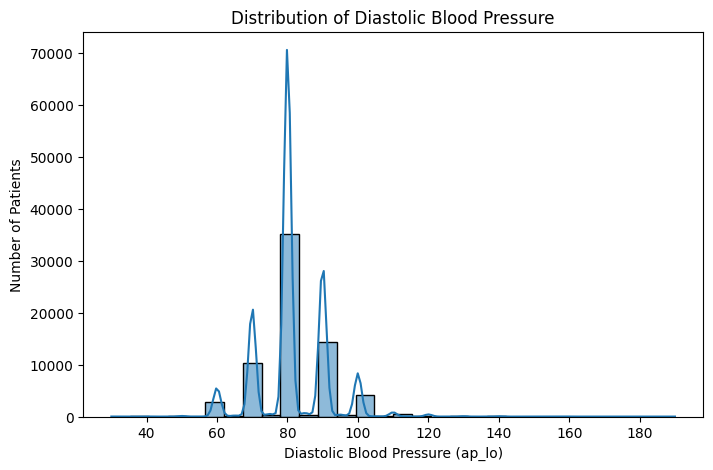

In [59]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x="ap_lo", bins=30, kde=True)

plt.title("Distribution of Diastolic Blood Pressure")
plt.xlabel("Diastolic Blood Pressure (ap_lo)")
plt.ylabel("Number of Patients")

plt.show()


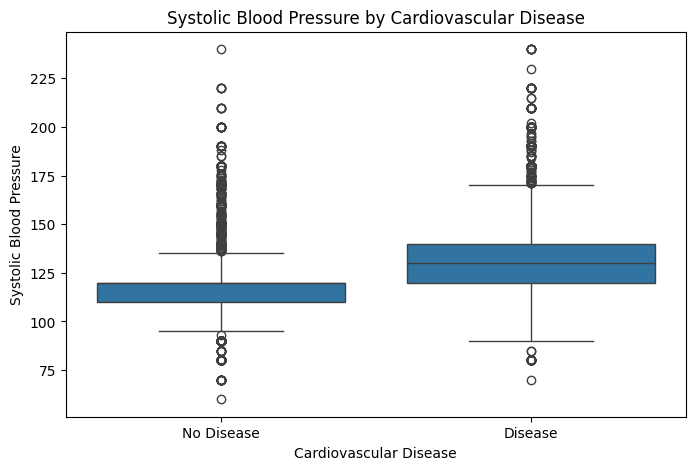

In [60]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="cardio", y="ap_hi")

plt.title("Systolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Systolic Blood Pressure")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

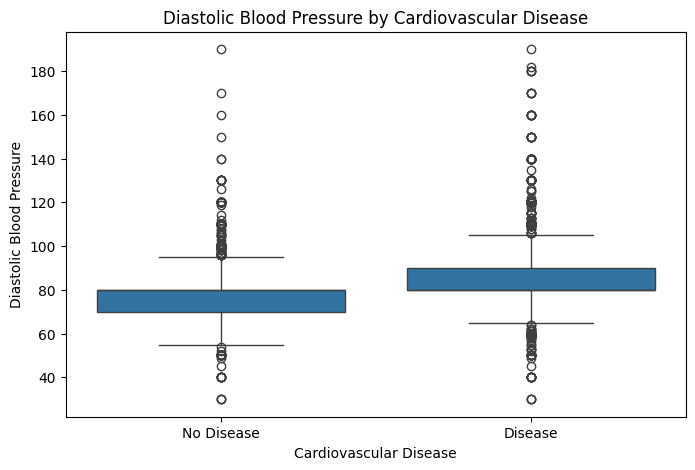

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="cardio", y="ap_lo")

plt.title("Diastolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Diastolic Blood Pressure")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

Analyze weight and BMI

In [62]:
# Convert height from centimeters to meters
df_clean["height_m"] = df_clean["height"] / 100

# Calculate BMI
df_clean["bmi"] = df_clean["weight"] / (df_clean["height_m"] ** 2)

# Check the result
df_clean[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


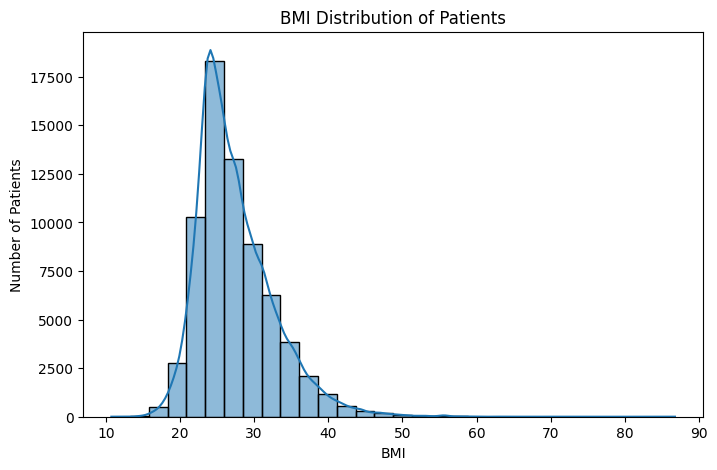

In [63]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x="bmi", bins=30, kde=True)

plt.title("BMI Distribution of Patients")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

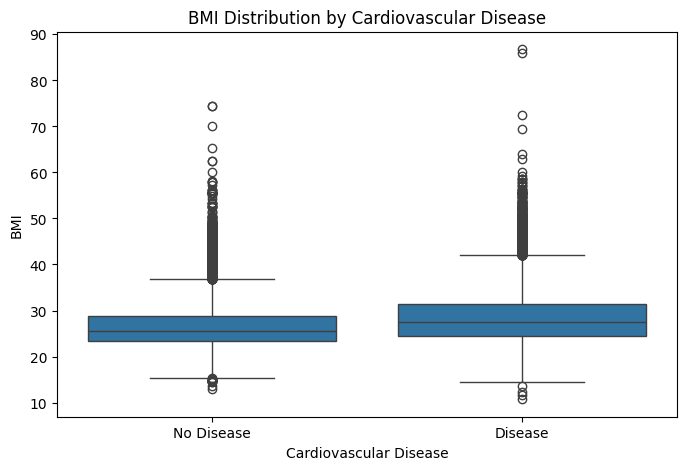

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="cardio", y="bmi")

plt.title("BMI Distribution by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("BMI")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

Correlation Matrix

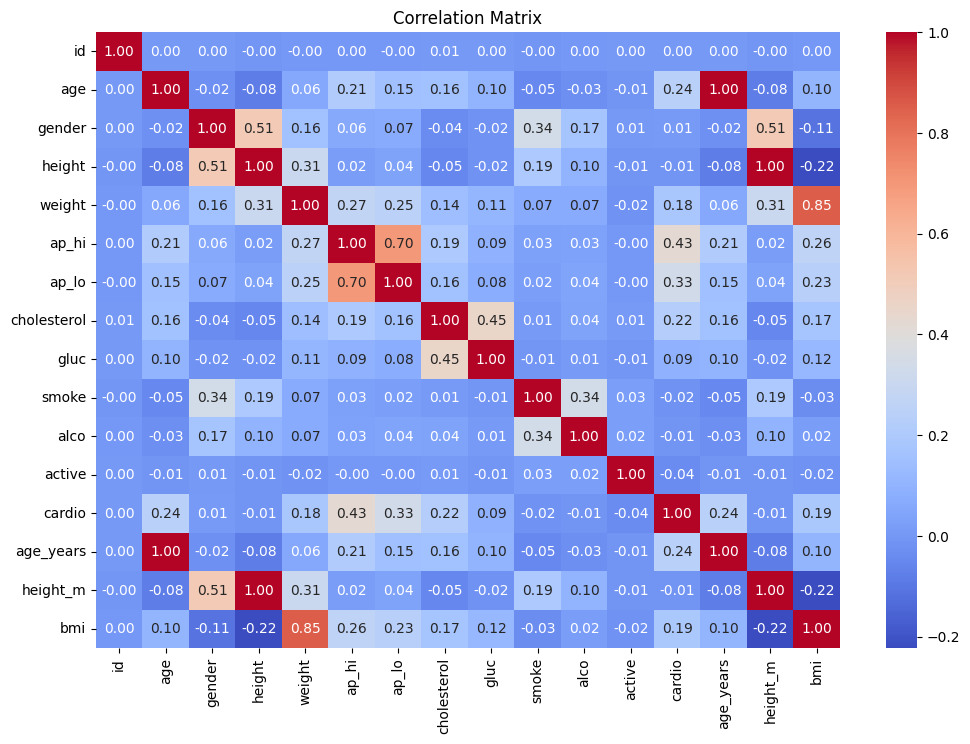

In [65]:
plt.figure(figsize=(12, 8))

corr = df_clean.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Prepare the features and target

In [66]:
# Create a copy for machine learning
model_df = df_clean.copy()

# Remove unnecessary columns
model_df = model_df.drop(columns=["id", "age", "height_m"])

# Separate features and target
X = model_df.drop(columns=["cardio"])
y = model_df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (68696, 12)
Target shape: (68696,)

Features:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi']


Split the data

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (54956, 12)
Testing features: (13740, 12)
Training target: (54956,)
Testing target: (13740,)


Scale the numerical features

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (54956, 12)
Scaled testing data shape: (13740, 12)


Train our first model: Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create the model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression Accuracy (%):", accuracy_lr * 100)

Logistic Regression Accuracy: 0.7264919941775837
Logistic Regression Accuracy (%): 72.64919941775837


KNN

In [70]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("KNN Accuracy (%):", accuracy_knn * 100)

KNN Accuracy: 0.6988355167394469
KNN Accuracy (%): 69.8835516739447


Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree Accuracy (%):", accuracy_dt * 100)

Decision Tree Accuracy: 0.7259097525473072
Decision Tree Accuracy (%): 72.59097525473072


Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Accuracy (%):", accuracy_rf * 100)

Random Forest Accuracy: 0.7093886462882096
Random Forest Accuracy (%): 70.93886462882097


 SVM

In [73]:
from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC(kernel="rbf", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("SVM Accuracy (%):", accuracy_svm * 100)

SVM Accuracy: 0.7333333333333333
SVM Accuracy (%): 73.33333333333333


evaluate our best model — SVM.

Confusion Matrix

Confusion Matrix:
[[5478 1463]
 [2201 4598]]


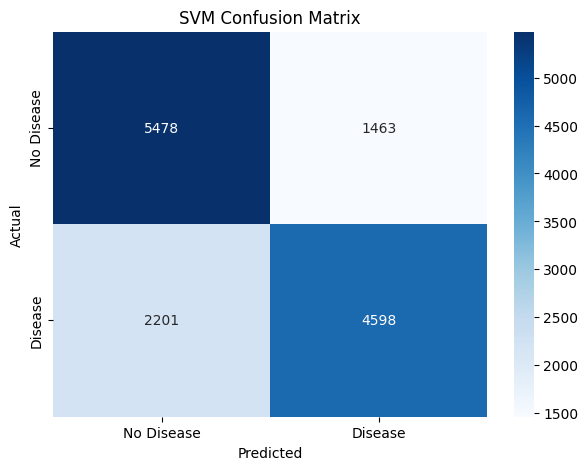

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [75]:
from sklearn.metrics import classification_report

print("SVM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["No Disease", "Disease"]
    )
)

SVM Classification Report:
              precision    recall  f1-score   support

  No Disease       0.71      0.79      0.75      6941
     Disease       0.76      0.68      0.72      6799

    accuracy                           0.73     13740
   macro avg       0.74      0.73      0.73     13740
weighted avg       0.74      0.73      0.73     13740



Prediction Function

In [82]:
def predict_heart_disease(
    gender,
    height,
    weight,
    ap_hi,
    ap_lo,
    cholesterol,
    gluc,
    smoke,
    alco,
    active,
    age_years
):
    # Calculate BMI
    height_m = height / 100
    bmi = weight / (height_m ** 2)

    # Create patient data with feature names
    patient_data = pd.DataFrame([{
        "gender": gender,
        "height": height,
        "weight": weight,
        "ap_hi": ap_hi,
        "ap_lo": ap_lo,
        "cholesterol": cholesterol,
        "gluc": gluc,
        "smoke": smoke,
        "alco": alco,
        "active": active,
        "age_years": age_years,
        "bmi": bmi
    }])

    # Scale the patient data
    patient_scaled = scaler.transform(patient_data)

    # Make prediction
    prediction = svm_model.predict(patient_scaled)

    if prediction[0] == 1:
        return "Cardiovascular Disease Detected"
    else:
        return "No Cardiovascular Disease Detected"

Test the Prediction System

In [83]:
result = predict_heart_disease(
    gender=2,
    height=168,
    weight=62,
    ap_hi=120,
    ap_lo=80,
    cholesterol=1,
    gluc=1,
    smoke=0,
    alco=0,
    active=1,
    age_years=50
)

print("Prediction:", result)

Prediction: No Cardiovascular Disease Detected


In [84]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm
    ]
})

# Convert accuracy to percentage
results["Accuracy (%)"] = results["Accuracy"] * 100

# Sort from highest to lowest
results = results.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Accuracy (%)
0,SVM,0.733333,73.333333
1,Logistic Regression,0.726492,72.649199
2,Decision Tree,0.725910,72.590975
3,Random Forest,0.709389,70.938865
4,KNN,0.698836,69.883552


Create a Model Accuracy Visualization

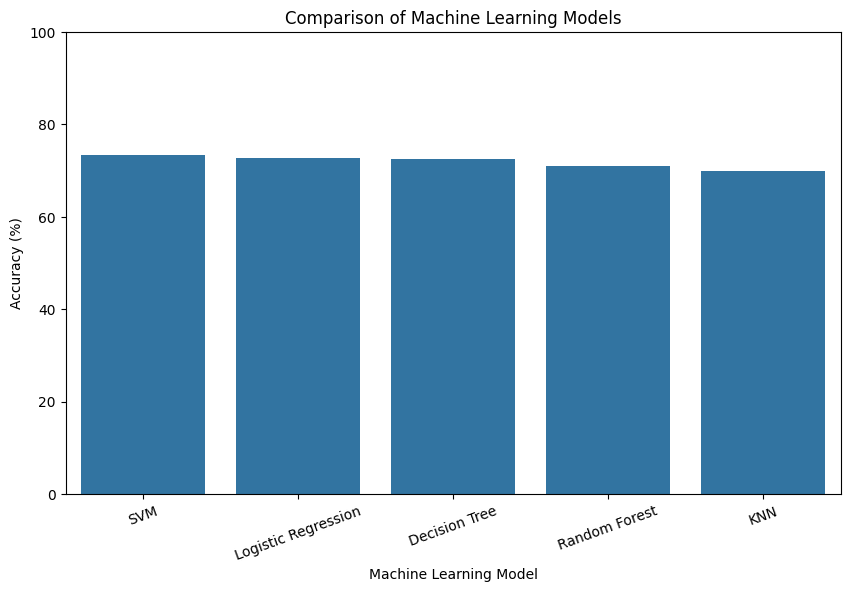

In [85]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)

plt.show()